In [1]:
import os

# Set the environment variables
os.environ["PYTORCH_NO_CUDA_MEMORY_CACHING"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:25,garbage_collection_threshold:0.5,expandable_segments:True"

# Verify the settings with improved output
print("Environment Variable Settings:")
print(f"  PYTORCH_NO_CUDA_MEMORY_CACHING: {os.environ.get('PYTORCH_NO_CUDA_MEMORY_CACHING', 'Not Set')}")
print(f"  PYTORCH_CUDA_ALLOC_CONF: {os.environ.get('PYTORCH_CUDA_ALLOC_CONF', 'Not Set')}")

print("-" * 30) # add a seperator.

Environment Variable Settings:
  PYTORCH_NO_CUDA_MEMORY_CACHING: 1
  PYTORCH_CUDA_ALLOC_CONF: max_split_size_mb:25,garbage_collection_threshold:0.5,expandable_segments:True
------------------------------


In [2]:
import pickle
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import numpy as np
import geneformer
from geneformer import TranscriptomeTokenizer
import scanpy as sc
import anndata as an
from datasets import Dataset, load_from_disk
from scipy.spatial.distance import cdist
import torch
import gc
from importlib import reload
import umap

# local functions
sys.path.append("../../utils/")
import geneformer_utils as ut

In [3]:
print(f"Torch Version: {torch.__version__}")
print(f"CUDA Version: {torch.version.cuda}")

Torch Version: 2.6.0+cu124
CUDA Version: 12.4


In [4]:
device = torch.device("cuda")
print(f"CUDA device available: {torch.cuda.get_device_name(0)}")

# Get total RAM
total_memory = torch.cuda.get_device_properties(0).total_memory
print(f"Total GPU memory: {total_memory / (1024**3):.2f} GB")

# Get allocated RAM
allocated_memory = torch.cuda.memory_allocated(0)
print(f"Allocated GPU memory: {allocated_memory / (1024**3):.2f} GB")

# Get cached RAM
cached_memory = torch.cuda.memory_reserved(0)
print(f"Cached GPU memory: {cached_memory / (1024**3):.2f} GB")

CUDA device available: NVIDIA A100 80GB PCIe MIG 3g.40gb
Total GPU memory: 39.25 GB
Allocated GPU memory: 0.00 GB
Cached GPU memory: 0.00 GB


In [5]:
# break

# Model choice

In [6]:
model_str = '95m'
params_file = "../../resources/geneformer_params.yaml"

with open(params_file, 'r') as file:
    params = yaml.safe_load(file)

model = params['models'][model_str]
print(json.dumps(model, indent=2))

{
  "model_path": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/gf-12L-95M-i4096/",
  "gene_median": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/gene_median_dictionary_gc95M.pkl",
  "token_dictionary_file": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/token_dictionary_gc95M.pkl",
  "gene_mapping_file": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/ensembl_mapping_dict_gc95M.pkl",
  "model_input_size": 4096,
  "special_token": true
}


# load the id mapping

In [7]:
with open(model['token_dictionary_file'], 'rb') as f:  
    tokens = pickle.load(f)

tokens_r = {v: k for k, v in tokens.items()}
print(f"{len(tokens)=}")

len(tokens)=20275


In [8]:
with open(model['gene_mapping_file'], 'rb') as f:  
    gene_map = pickle.load(f)

print(f"{len(gene_map)=}")

len(gene_map)=173697


In [9]:
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']

tf_df = []
for tf in tf_recipe:
    ens_id = gene_map[tf]
    token_id = tokens[ens_id]
    tf_df.append((tf, ens_id, token_id))

tf_df = pd.DataFrame(tf_df, columns=["TF", "ensembl_ID", "token_ID"])
print(tf_df.to_string(index=False))

    TF      ensembl_ID  token_ID
 GATA2 ENSG00000179348     14205
 GFI1B ENSG00000165702     11475
   FOS ENSG00000170345     12558
STAT5A ENSG00000126561      5761
   REL ENSG00000162924     10694


# Load the tokenized data

In [10]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer/pseudotime.dataset"

data = load_from_disk(fpath)
print(f"{data.shape=}")

df = data.to_pandas()
df.head()

data.shape=(15867, 11)
CPU times: user 36.8 ms, sys: 85 ms, total: 122 ms
Wall time: 130 ms


,input_ids,batch,phase,n_counts,mean_pseudotime,mean_order,nnz,S_score,G2M_score,cluster_str,length
0,"[2, 10172, 10171, 2839, 2706, 15305, 14422, 27...",hsc,G1,3679,0.808782,0.0,3679,-0.005952,-1.192717,C3,3436
1,"[2, 17488, 17862, 15445, 13841, 17068, 6943, 6...",hsc,G1,3987,0.922000,7688.0,3987,-0.198413,-1.039894,C3,3679
2,"[2, 10172, 13391, 18079, 14211, 283, 1136, 197...",hsc,S,2585,0.264203,9543.0,2585,0.714286,-0.243658,C4,2418
3,"[2, 12826, 18282, 19836, 8699, 2968, 18815, 72...",hsc,G1,2358,0.295864,15150.0,2358,-0.121032,-0.625818,C5,2228
4,"[2, 145, 20006, 19409, 18880, 18408, 11013, 78...",hsc,G1,4995,0.787087,6684.0,4995,-0.444444,-2.328151,C2,4096


In [11]:
gdf = pd.DataFrame.from_dict(
    gene_map, 
    orient='index', 
    columns=['gene_id'],
).reset_index(names='gene_name')
print(f"Raw: {gdf.shape=}")
gdf = gdf.drop_duplicates('gene_id')
print(f"Filtered: {gdf.shape=}")
gdf = gdf.set_index('gene_id')

gdf.head()

Raw: gdf.shape=(173697, 2)
Filtered: gdf.shape=(63675, 2)


,gene_name
gene_id,
ENSG00000277411,5S_RRNA
ENSG00000277739,RNA5-8SP10
ENSG00000271394,7SK
ENSG00000121410,ABG
ENSG00000268895,A1BG-AS1


['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']


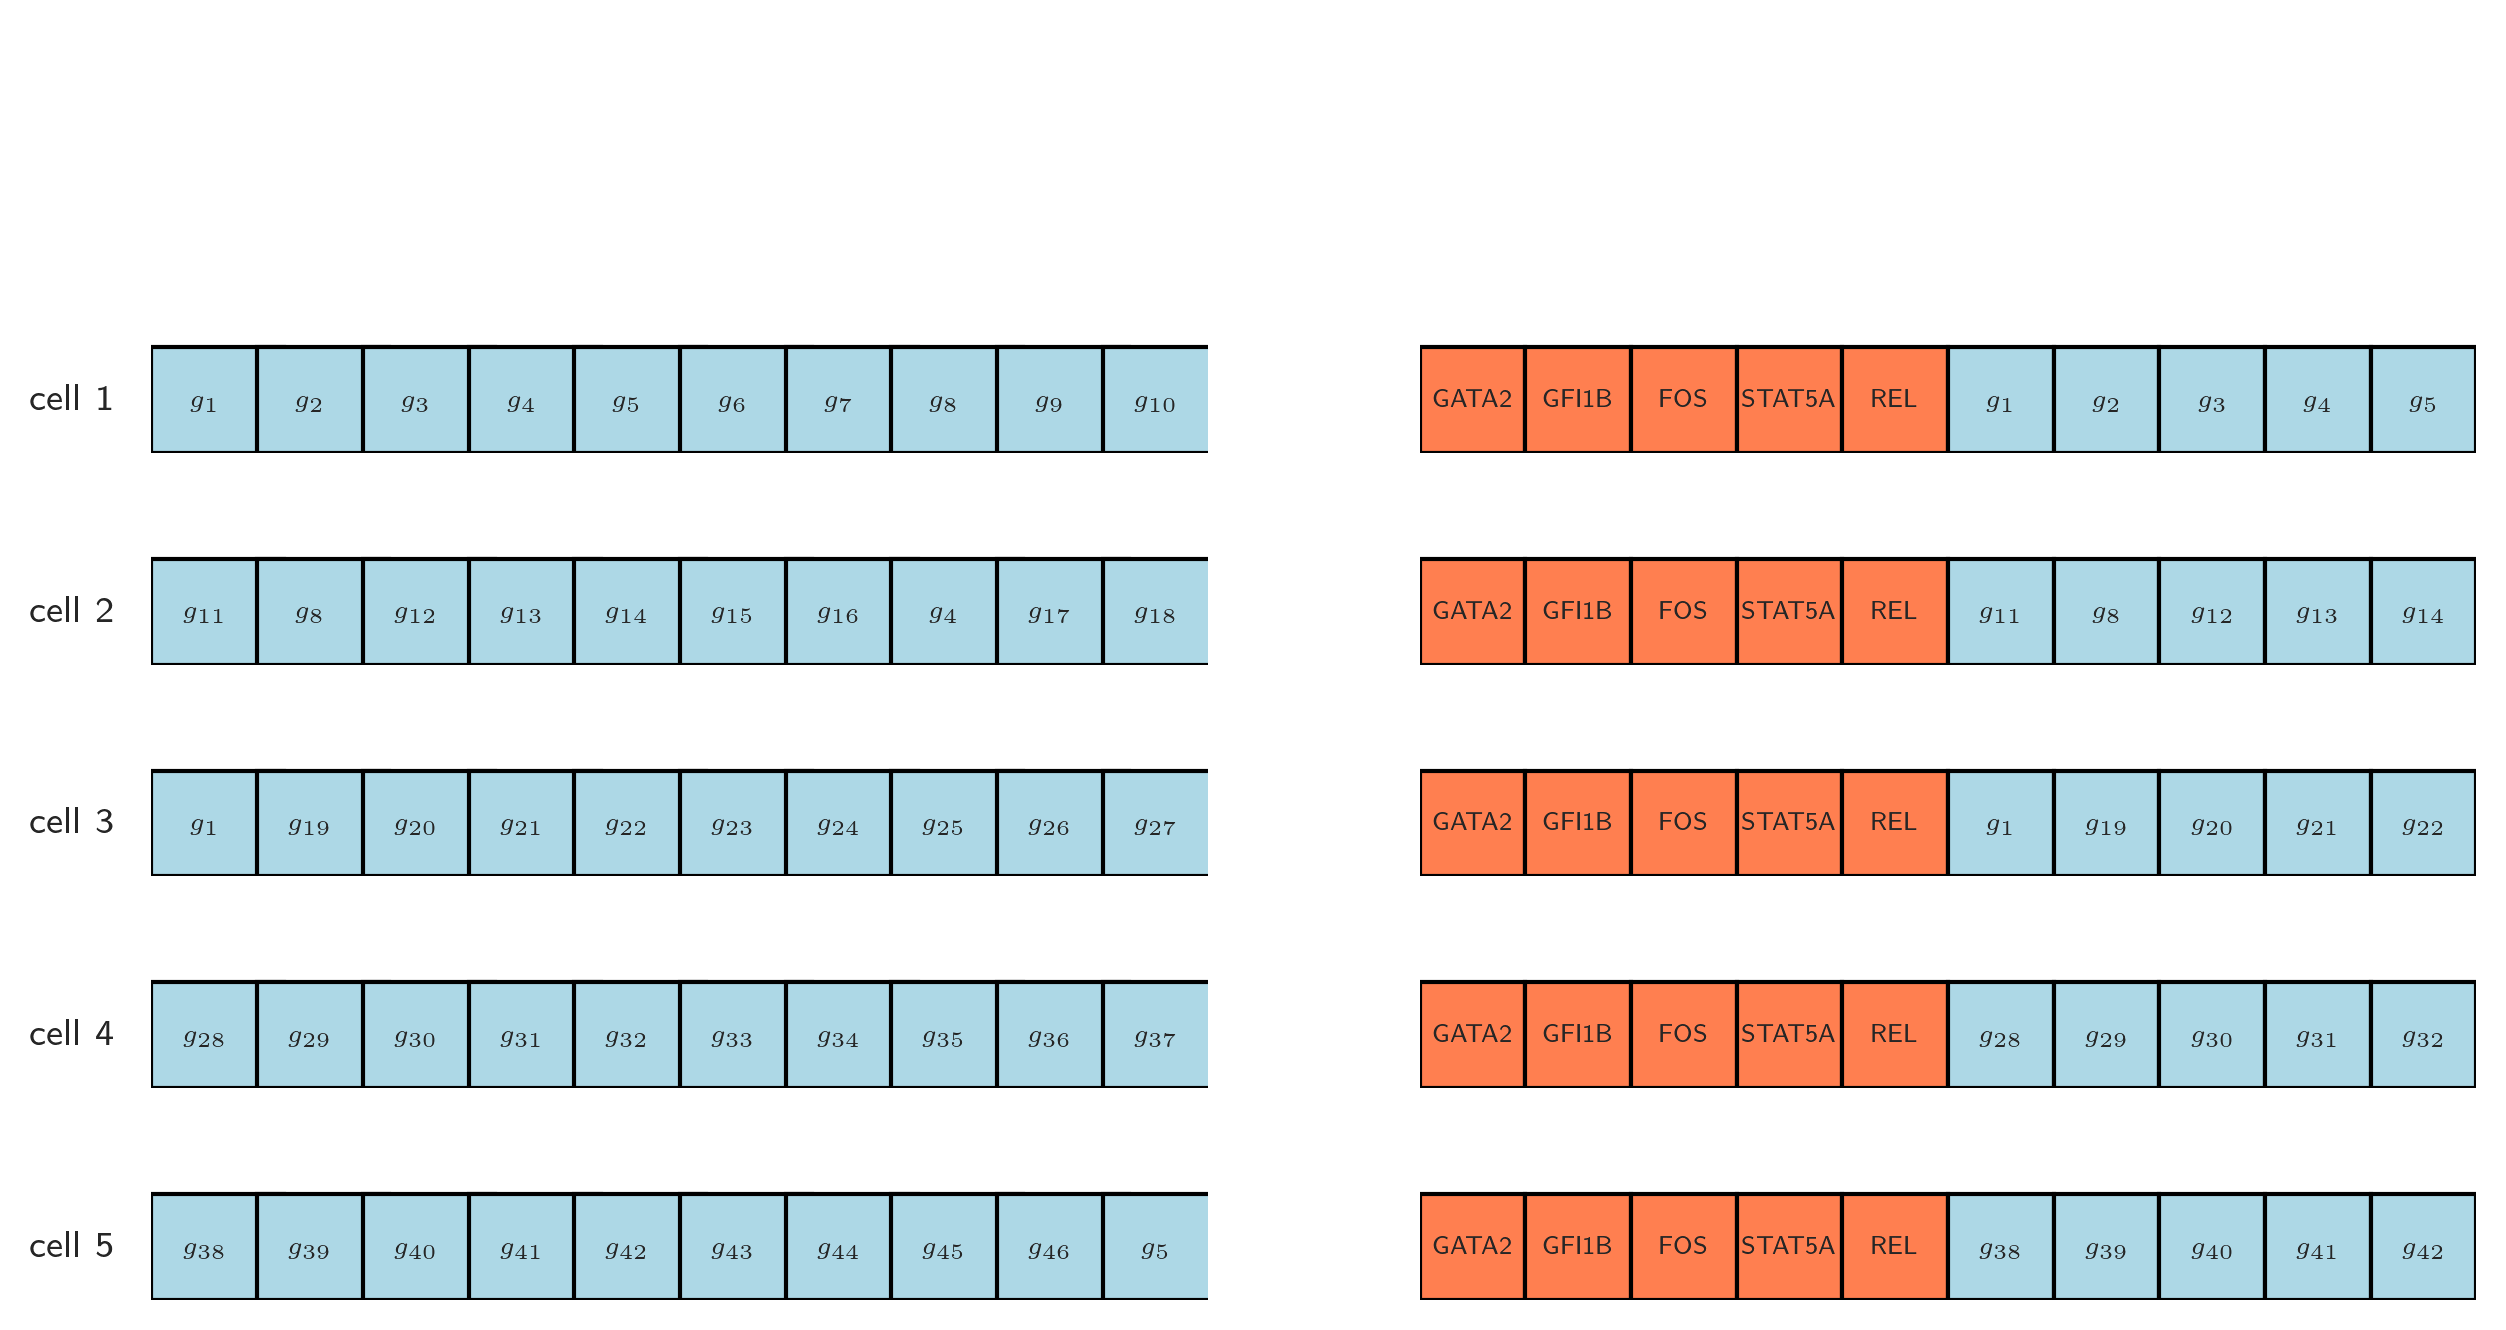

In [12]:
tf_list = tf_df['TF'].to_list()
print(tf_list)
n_cells = 5
n_genes = 10

cells = df.head(n_cells).copy()

rve = cells['input_ids'].apply(lambda x: x[1:n_genes+1])

# Flatten all tokens and get unique set
unique_tokens = pd.unique(rve.explode())

# Create a mapping from token to consistent gene_id
token_to_gene_id = {tok: f'g_{i+1}' for i, tok in enumerate(unique_tokens)}

# Apply mapping
rve_with_gene_ids = rve.apply(lambda tokens: [token_to_gene_id[tok] for tok in tokens])

# Plotting
plt.rcParams['text.usetex'] = True
fig, axes = plt.subplots(
    n_cells, 2,
    figsize=(10, 1.1 * n_cells),  # reduce vertical figure size too
    sharex=True,
    dpi=300,
    gridspec_kw={'hspace': -0.5}
)

for i, tokens in enumerate(rve_with_gene_ids):

    # Get perturbed version by prepending TFs and truncating to n_genes
    perturbed_tokens = (tf_list + tokens)[:n_genes]

    fontsize = 6
    boxcolor = 'lightblue'

    axes[i, 0].text(-0.75, 0.125, f'cell {i+1}', ha='center', va='center', fontsize=9)
    
    for k, val in enumerate(tokens):
        prefix, sub = val.split('_')

        # unperturbed
        axes[i, 0].add_patch(plt.Rectangle((k, 0), 1.25, 0.25, edgecolor='black', facecolor=boxcolor))
        axes[i, 0].text(k + 0.5, 0.125, f"${prefix}_{{{sub}}}$", ha='center', va='center', fontsize=fontsize)
        axes[i, 0].set_xlim(0, n_genes)
        axes[i, 0].set_ylim(0, 1)
        axes[i, 0].axis('off')

    for k, val in enumerate(perturbed_tokens):

        if "_" in val:
            prefix, sub = val.split('_')
            text = f"${prefix}_{{{sub}}}$"
            boxcolor = 'lightblue'
        else:
            text = val
            boxcolor = "coral"

        # perturbed
        axes[i, 1].add_patch(plt.Rectangle((k, 0), 1, 0.25, edgecolor='black', facecolor=boxcolor))
        axes[i, 1].text(k + 0.5, 0.125, text, ha='center', va='center', fontsize=fontsize)
        axes[i, 1].set_xlim(0, n_genes)
        axes[i, 1].set_ylim(0, 1)
        axes[i, 1].axis('off')

    # break  # remove this to plot all cells

# plt.tight_layout()
plt.show()

# Perturb

In [13]:
def adjust_input_ids(ids, tf_list, max_len=4096):
    """
    Prepend tf_list to the input ids, then trim or pad so that:
    - The total length is max_len
    - The original first and last elements of ids remain unchanged.
    """
    if len(ids) < 2:
        raise ValueError("ids must contain at least two elements")

    first, last = ids[0], ids[-1]
    middle = ids[1:-1]

    # Prepend tf_list to the middle section
    new_middle = tf_list + middle

    # Desired length for the middle section
    target_mid_len = max_len - 2

    # Trim if too long
    if len(new_middle) > target_mid_len:
        new_middle = new_middle[:target_mid_len]
    # Pad if too short
    elif len(new_middle) < target_mid_len:
        pad_needed = target_mid_len - len(new_middle)
        new_middle += tf_list[:pad_needed]

    # Reconstruct with original first and last
    return [first] + new_middle + [last]


tf_list = tf_df['token_ID'].to_list()

# get control cells in each phase
tf_list = tf_df['token_ID'].to_list()

perturbed = []
unperturbed = []

for phase in ['G1', 'S', 'G2M']:
    print(f"working {phase}...")
    data = df[(df['phase'] == phase) & (df['batch'] == 'fib')].reset_index(drop=True)
    data['cell_id'] = [f"{phase}_{x+1}" for x in range(len(data))]
    data['stage'] = 'initial'
    unperturbed.append(data.copy())

    # add the TFs
    data['input_ids'] = data['input_ids'].apply(lambda x: adjust_input_ids(list(x), tf_list)).copy()
    data['stage'] = 'TF'
    perturbed.append(data)


unperturbed = pd.concat(unperturbed, ignore_index=True)  
print(f"{unperturbed.shape=}")
print(unperturbed[['input_ids', 'cluster_str', 'batch', 'cell_id']].head())
print()

perturbed = pd.concat(perturbed, ignore_index=True)  
print(f"{perturbed.shape=}")
print(perturbed[['input_ids', 'cluster_str', 'batch', 'cell_id']].head())

working G1...
working S...
working G2M...
unperturbed.shape=(7541, 13)
                                           input_ids cluster_str batch cell_id
0  [2, 20165, 283, 15343, 859, 11250, 7071, 4387,...          C5   fib    G1_1
1  [2, 283, 7071, 11714, 4230, 9106, 872, 17125, ...          C5   fib    G1_2
2  [2, 20165, 19409, 283, 11250, 2838, 7787, 9186...          C5   fib    G1_3
3  [2, 20165, 17267, 11250, 283, 7787, 18699, 117...          C5   fib    G1_4
4  [2, 20184, 14422, 7071, 283, 7787, 7094, 8794,...          C5   fib    G1_5

perturbed.shape=(7541, 13)
                                           input_ids cluster_str batch cell_id
0  [2, 14205, 11475, 12558, 5761, 10694, 20165, 2...          C5   fib    G1_1
1  [2, 14205, 11475, 12558, 5761, 10694, 283, 707...          C5   fib    G1_2
2  [2, 14205, 11475, 12558, 5761, 10694, 20165, 1...          C5   fib    G1_3
3  [2, 14205, 11475, 12558, 5761, 10694, 20165, 1...          C5   fib    G1_4
4  [2, 14205, 11475, 12558, 5761

<!-- break -->

# Model Definition

In [14]:
gene_median = model['gene_median']
token_dictionary_file = model['token_dictionary_file']
gene_mapping_file = model['gene_mapping_file']

In [15]:
# load and reverse the token mapping
token_dict = ut.load_pickle(token_dictionary_file)
token_dict = {v: k for k, v in token_dict.items()} # WHY?
print(f"{len(token_dict)=}")

model_obj = ut.load_model(model['model_path'])
# print(model_obj)
print('ready!')

len(token_dict)=20275
ready!


# Cell Emebdddings

In [16]:
sample_size = 7000

# sample and combine
pdf = df[df['batch'] == 'hsc'].copy()
pdf['cell_id'] = [f"hsc_{x+1}" for x in range(len(pdf))]
pdf['stage'] = 'target'

pdf = pd.concat([pdf, unperturbed, perturbed])
print(f"Raw: {pdf.shape=}")

pdf = pdf.groupby('stage').sample(n=sample_size, random_state=42)
print(f"Sampled: {pdf.shape=}")

print(pdf[['batch', 'phase', 'cluster_str', 'stage']].head().to_string())

Raw: pdf.shape=(23408, 13)
Sampled: pdf.shape=(21000, 13)
     batch phase cluster_str stage
3045   fib    G1          C5    TF
5484   fib   G2M          C4    TF
1616   fib    G1          C5    TF
6348   fib   G2M          C4    TF
6357   fib   G2M          C4    TF


In [17]:
%%time
torch.cuda.empty_cache()

edata = ut.extract_cell_embeddings(
    model=model_obj,
    data=Dataset.from_pandas(pdf),
    token_gene_dict=token_dict,
    layer_to_quant=0,
    forward_batch_size=10,
)

edata.obs.head()

CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


  0%|          | 0/2100 [00:00<?, ?it/s]

CPU times: user 34min 48s, sys: 1min 13s, total: 36min 1s
Wall time: 36min 14s


,input_ids,batch,phase,n_counts,mean_pseudotime,mean_order,nnz,S_score,G2M_score,cluster_str,length,cell_id,stage,__index_level_0__
0,[ 2 14205 11475 ... 5761 10694 3],fib,G1,3077,0.2724253535270691,14291.0,3077,-0.3055555555555556,-2.2125613747954174,C5,2892,G1_3046,TF,3045
1,[ 2 14205 11475 ... 5761 10694 3],fib,G2M,3384,0.33106616139411926,11492.0,3384,0.049603174603174593,1.0963584288052373,C4,3163,G2M_353,TF,5484
2,[ 2 14205 11475 ... 5761 10694 3],fib,G1,3892,0.25958582758903503,13763.0,3892,-0.32539682539682535,-2.663052373158756,C5,3666,G1_1617,TF,1616
3,[ 2 14205 11475 ... 5761 10694 3],fib,G2M,3517,0.249418243765831,9112.5,3517,0.5634920634920635,0.6808510638297873,C4,3316,G2M_1217,TF,6348
4,[ 2 14205 11475 ... 5761 10694 3],fib,G2M,3772,0.3209768831729889,11299.0,3772,-0.04365079365079366,1.9324877250409171,C4,3588,G2M_1226,TF,6357


# Plot 

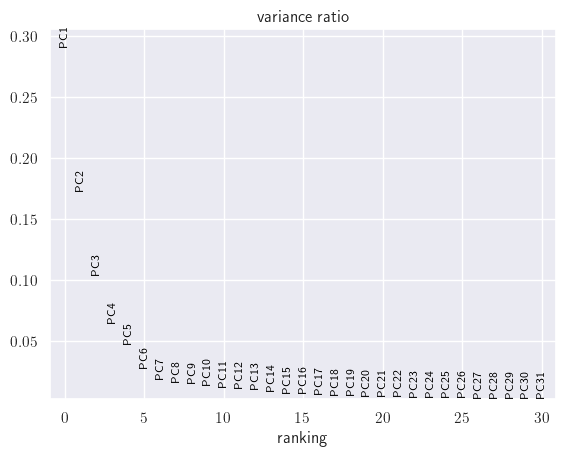

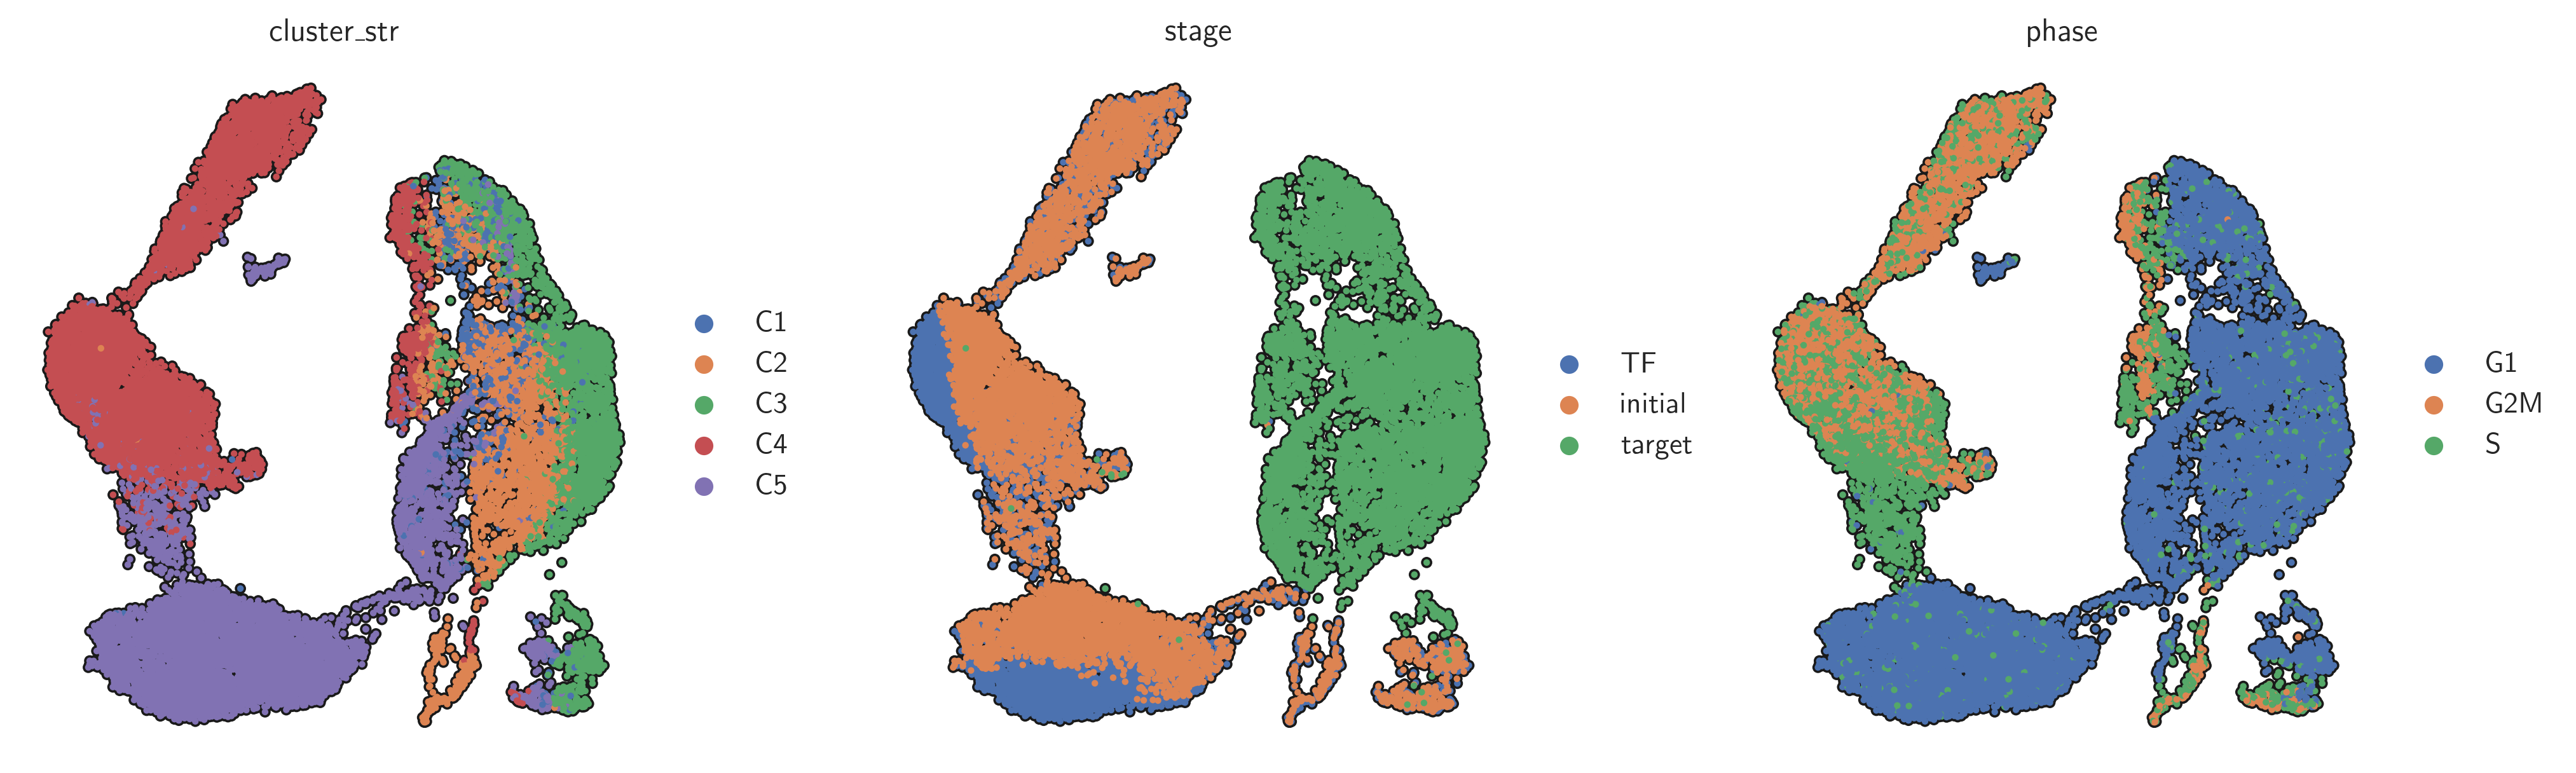

CPU times: user 41 s, sys: 4.69 s, total: 45.7 s
Wall time: 40.7 s


In [18]:
%%time
sc.pp.pca(edata)
sc.pl.pca_variance_ratio(edata)
sc.pp.neighbors(edata)
sc.tl.umap(edata)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.25, 4.75

sc.pl.umap(
    edata, 
    color=["cluster_str", 'stage', 'phase'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.25,
)


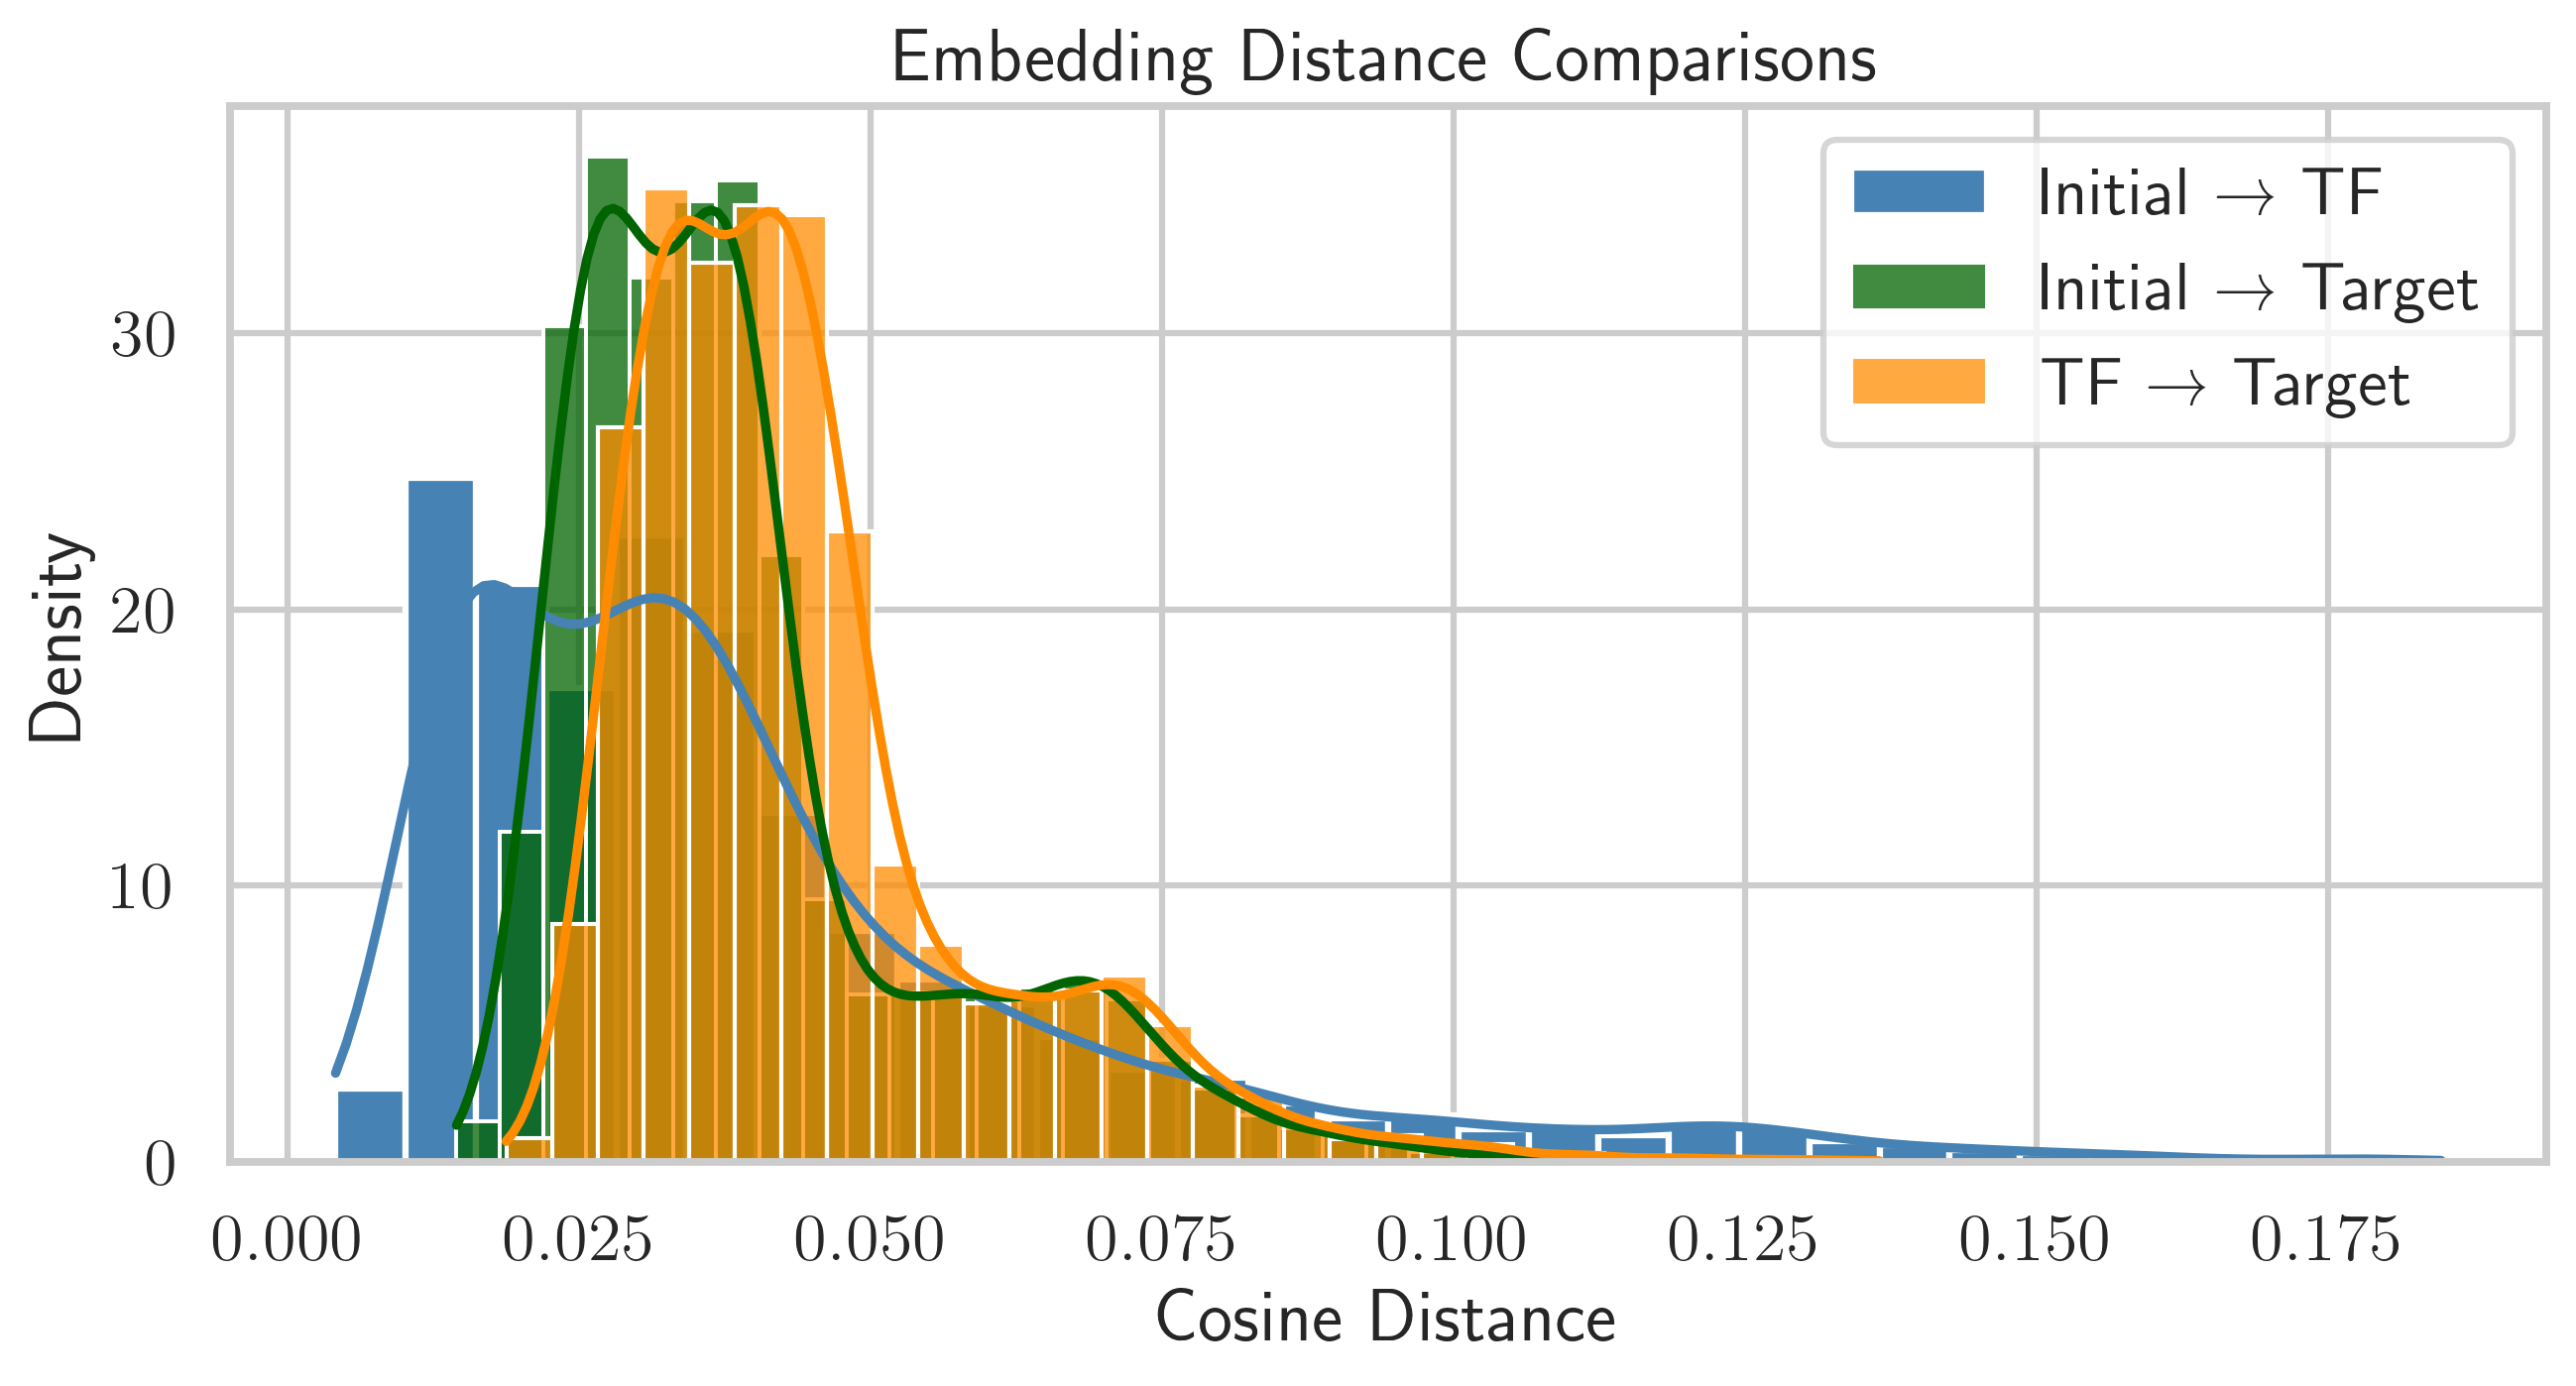

CPU times: user 14.8 s, sys: 1.59 s, total: 16.4 s
Wall time: 14.9 s


In [19]:
%%time

# Configurable distance metric
# distance_metric = "euclidean"  # change to "cosine", "cityblock", etc.
distance_metric = "cosine"  # change to "cosine", "cityblock", etc.

# Extract and convert
X = edata[edata.obs['stage'] == 'initial'].X
Y = edata[edata.obs['stage'] == 'TF'].X
Z = edata[edata.obs['stage'] == 'target'].X

X = X.toarray() if hasattr(X, 'toarray') else X
Y = Y.toarray() if hasattr(Y, 'toarray') else Y
Z = Z.toarray() if hasattr(Z, 'toarray') else Z

# Validate shapes
if X.shape[0] != Y.shape[0]:
    raise ValueError("X and Y must have the same number of rows")
if X.shape[1] != Z.shape[1]:
    raise ValueError("Feature mismatch between X and Z")

# Mean target
Z_mean = Z.mean(axis=0, keepdims=True)

# Compute pairwise distances
dist_XY = cdist(X, Y, metric=distance_metric).diagonal()  # paired
dist_XZ = cdist(X, Z_mean, metric=distance_metric).flatten()  # all to mean
dist_YZ = cdist(Y, Z_mean, metric=distance_metric).flatten()  # all to mean

# Store for plotting
distances = {
    'Initial → TF': dist_XY,
    'Initial → Target': dist_XZ,
    'TF → Target': dist_YZ
}

colors = {
    'Initial → TF': 'steelblue',
    'Initial → Target': 'darkgreen',
    'TF → Target': 'darkorange'
}

# Plot
sns.set(style="whitegrid", context="talk")
plt.figure(dpi=300, figsize=(9, 5))

for label, dist in distances.items():
    sns.histplot(dist, bins=30, kde=True, stat='density',
                 label=label, color=colors[label], alpha=0.75 if "Target" in label else 1)

plt.xlabel(f"{distance_metric.capitalize()} Distance")
plt.ylabel("Density")
plt.title("Embedding Distance Comparisons")
plt.legend()
plt.tight_layout()
plt.show()


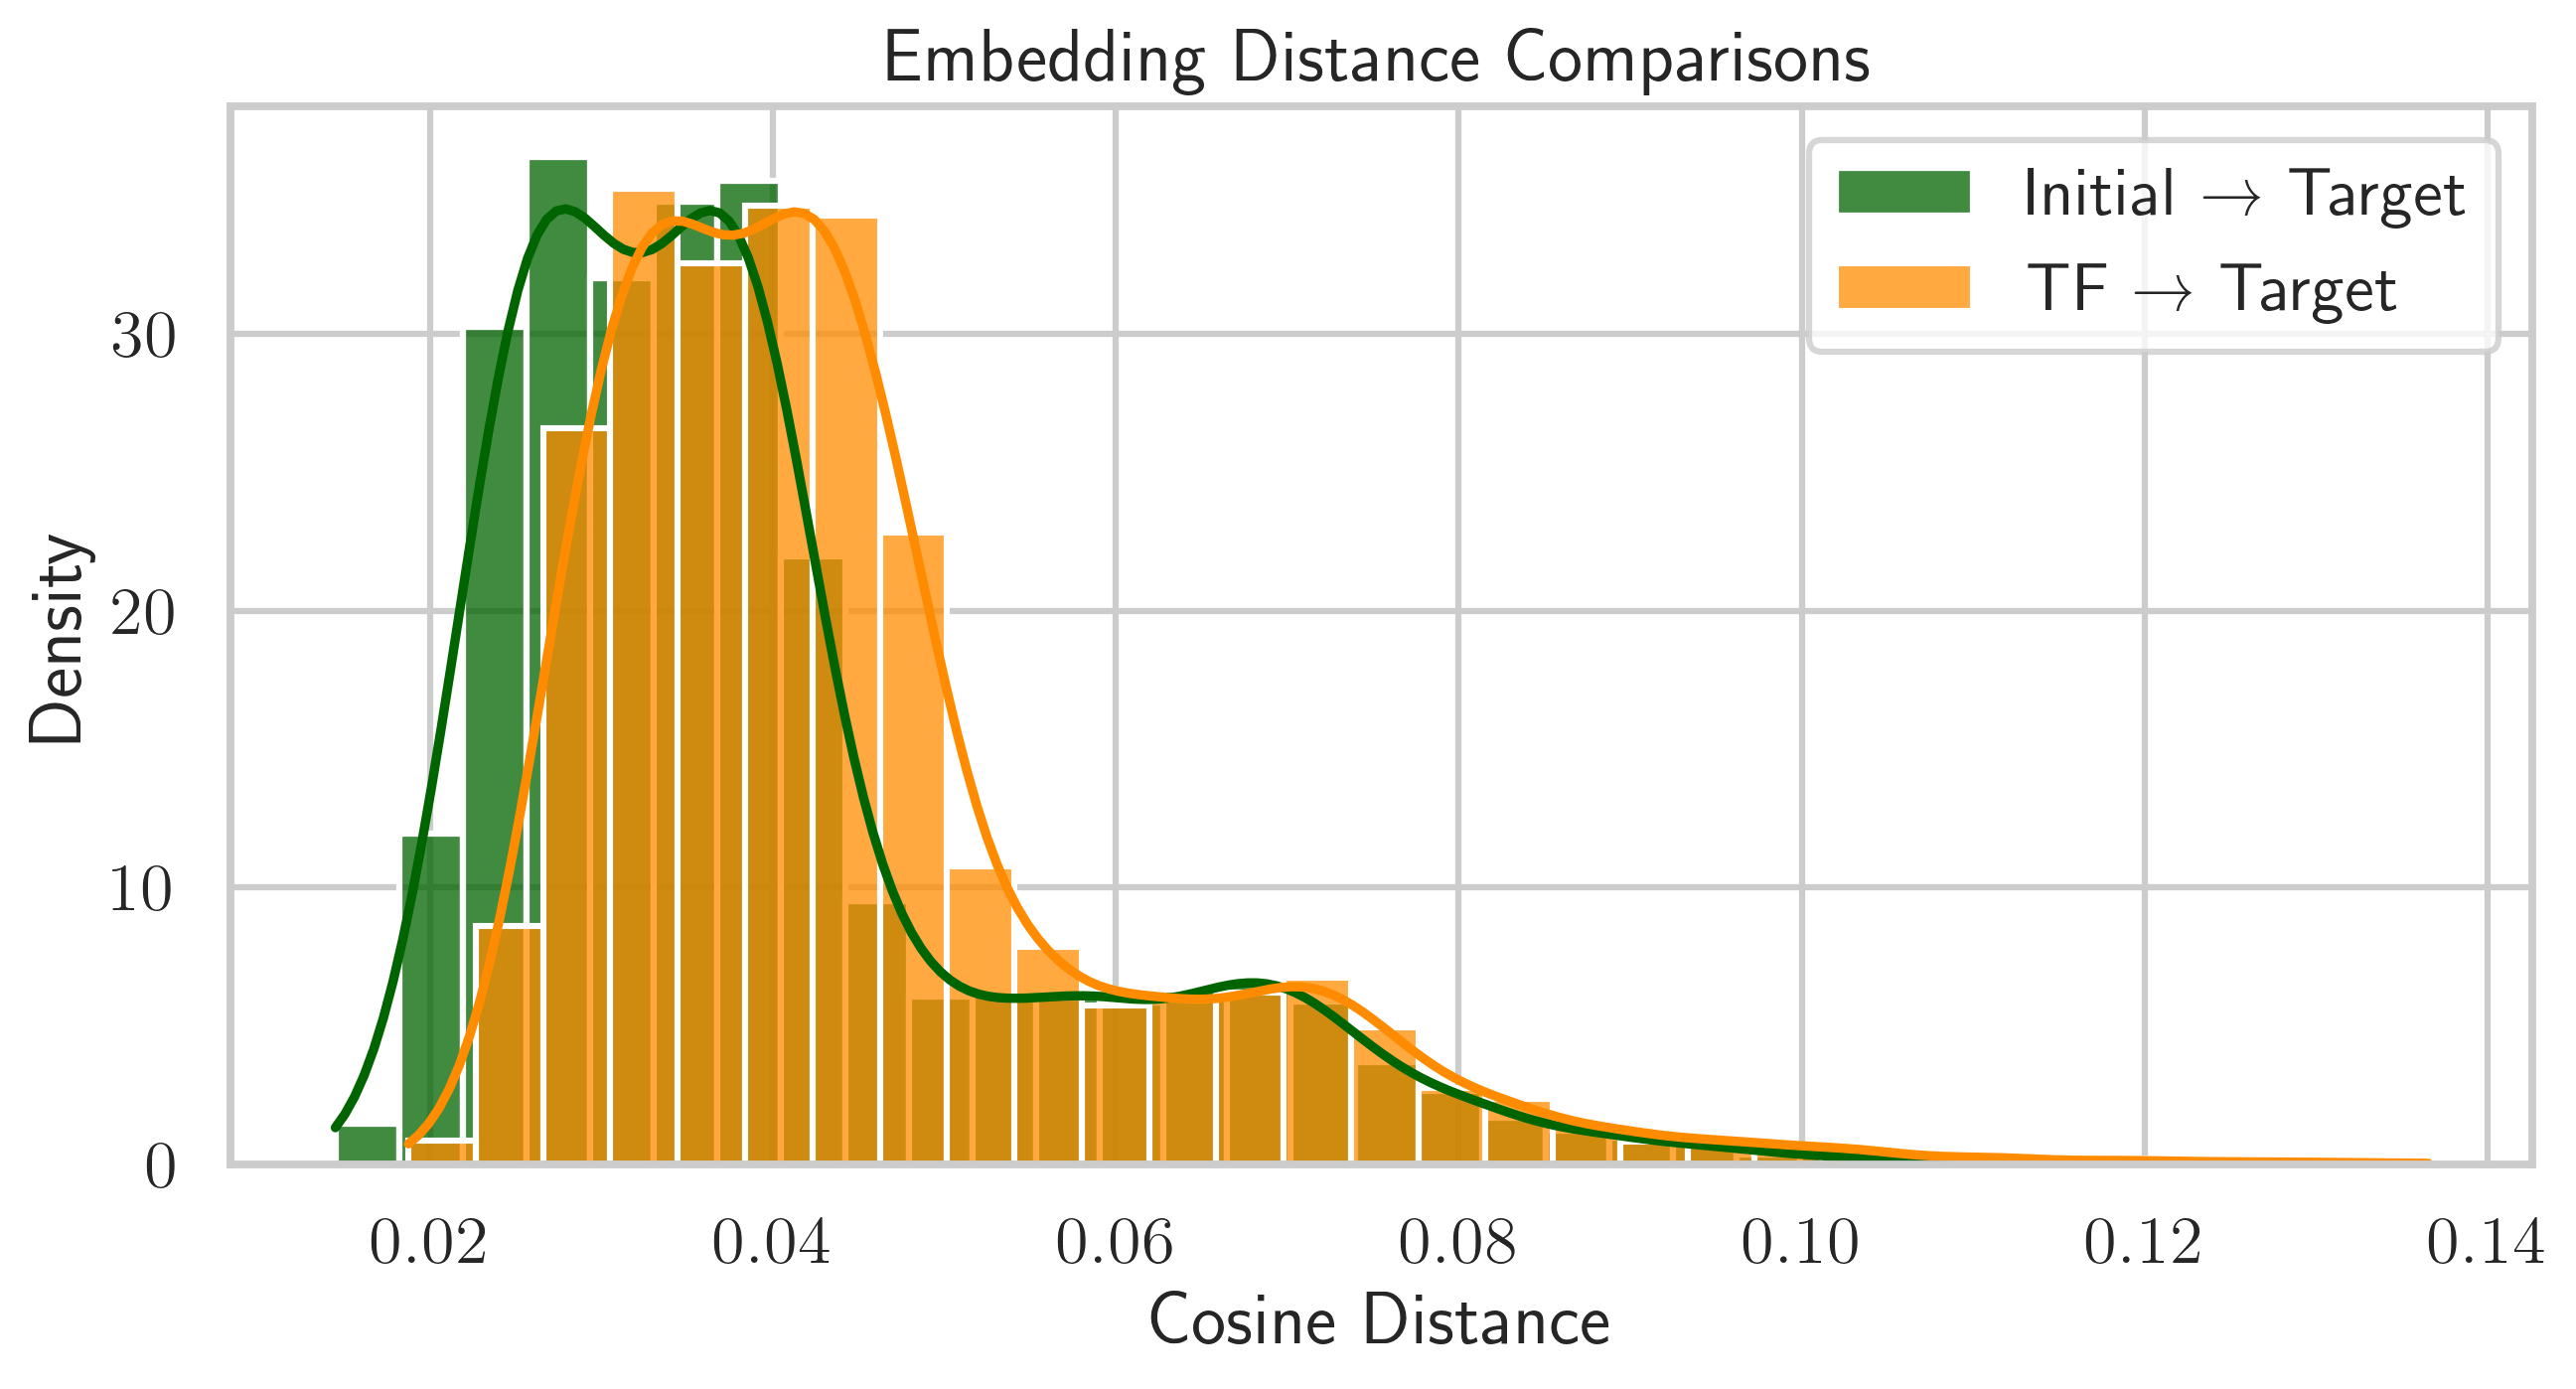

In [20]:
# Plot
sns.set(style="whitegrid", context="talk")
plt.figure(dpi=300, figsize=(9, 5))

for label, dist in distances.items():
    if label == 'Initial → TF':
        continue
    sns.histplot(dist, bins=30, kde=True, stat='density',
                 label=label, color=colors[label], alpha=0.75 if "Target" in label else 1)

plt.xlabel(f"{distance_metric.capitalize()} Distance")
plt.ylabel("Density")
plt.title("Embedding Distance Comparisons")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3540268/254042324.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


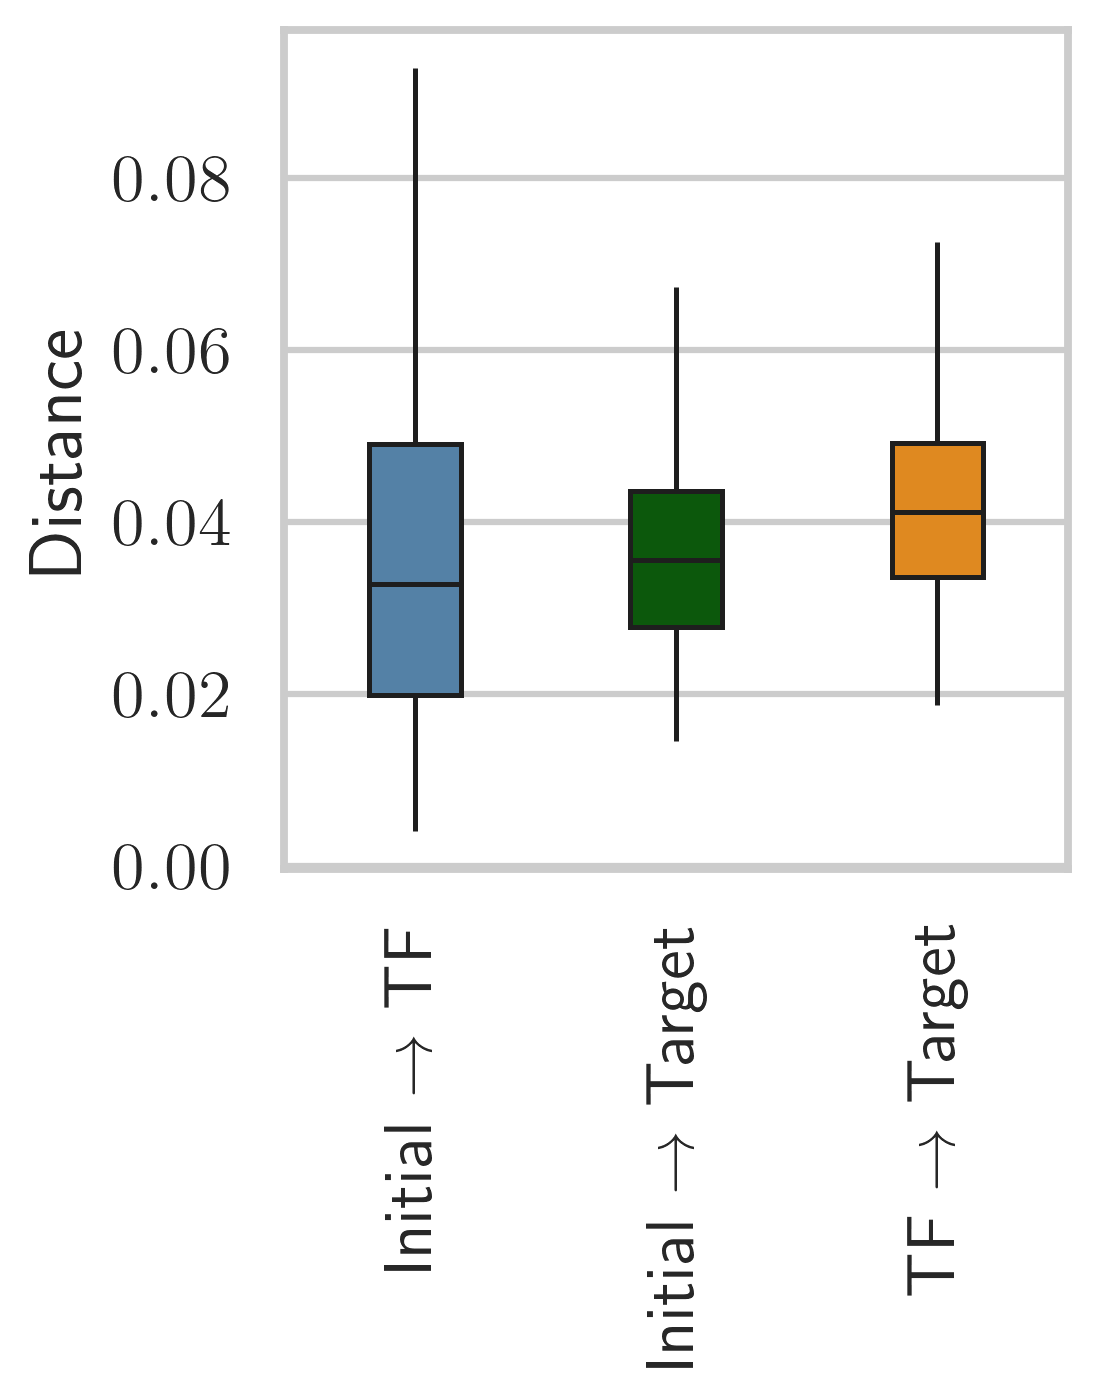

In [36]:
# Prepare data for boxplot
plot_df = pd.DataFrame({
    'Distance': np.concatenate([dist_XY, dist_XZ, dist_YZ]),
    'Comparison': (
        ['Initial → TF'] * len(dist_XY) +
        ['Initial → Target'] * len(dist_XZ) +
        ['TF → Target'] * len(dist_YZ)
    )
})

# Plot
sns.set(style="whitegrid", context="talk")
plt.figure(dpi=300, figsize=(4, 5))

sns.boxplot(
    data=plot_df,
    x='Comparison', 
    y='Distance', 
    palette=colors,
    linewidth=1.2,
    showfliers=False, 
    capprops={'lw':0},
    width=0.35,
)

plt.gca().tick_params(axis='x', rotation=90)
plt.xlabel("")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3540268/816348661.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


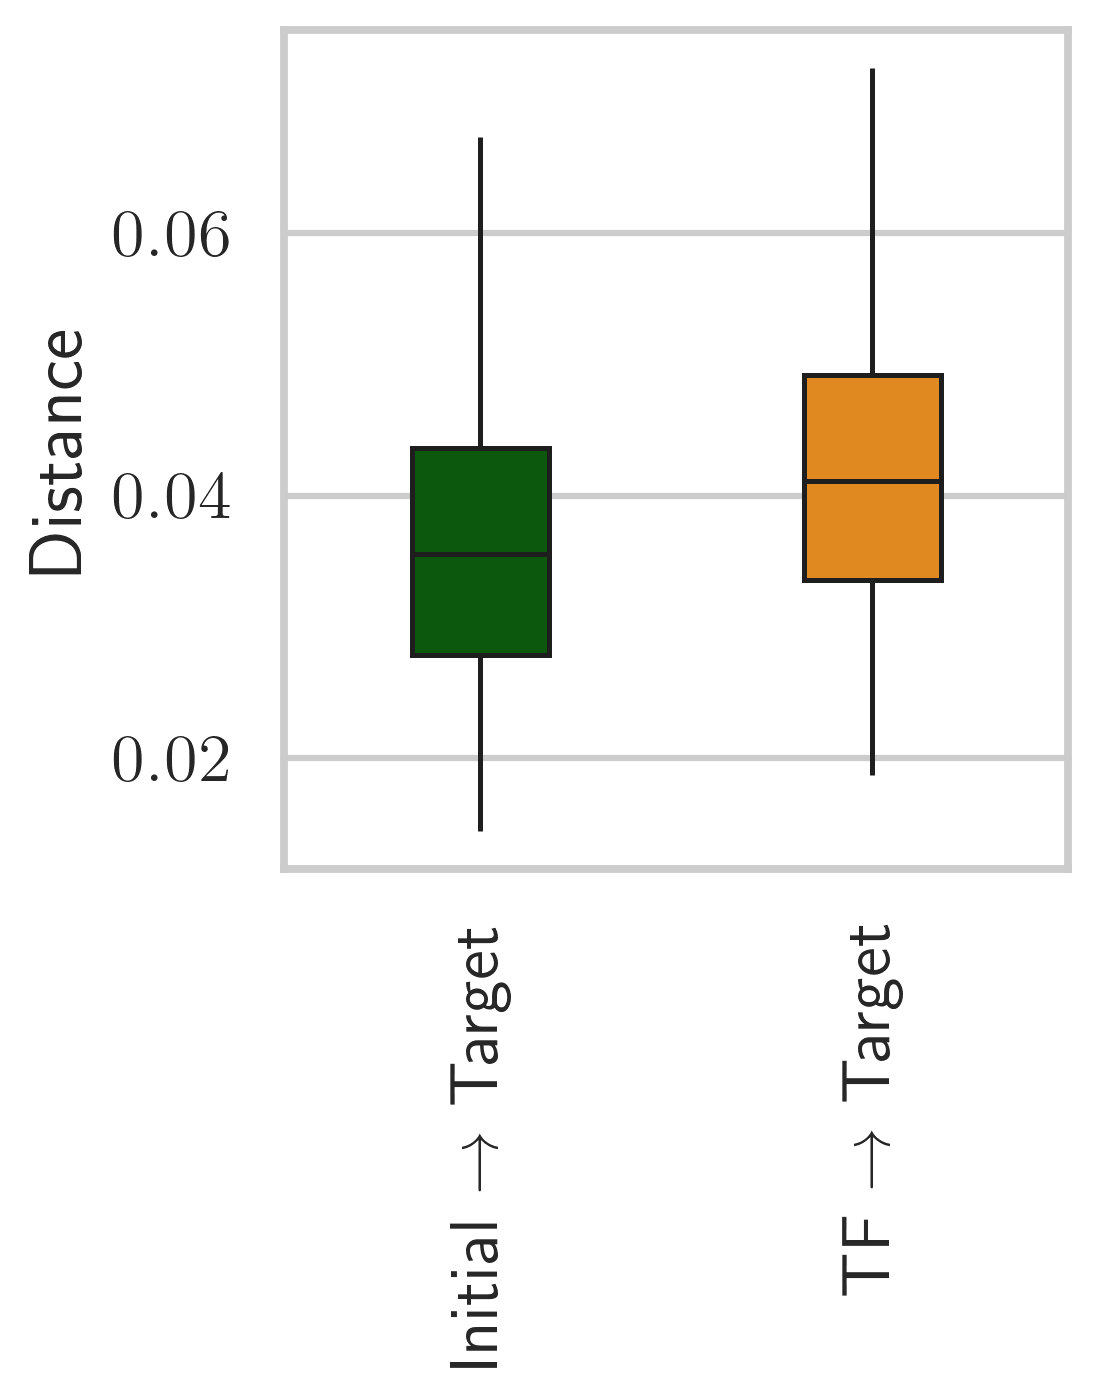

In [40]:
# Prepare data for boxplot
plot_df = pd.DataFrame({
    'Distance': np.concatenate([dist_XY, dist_XZ, dist_YZ]),
    'Comparison': (
        ['Initial → TF'] * len(dist_XY) +
        ['Initial → Target'] * len(dist_XZ) +
        ['TF → Target'] * len(dist_YZ)
    )
})

plot_df = plot_df[plot_df['Comparison'] != 'Initial → TF']

# Plot
sns.set(style="whitegrid", context="talk")
plt.figure(dpi=300, figsize=(4, 5))

sns.boxplot(
    data=plot_df,
    x='Comparison', 
    y='Distance', 
    palette=colors,
    linewidth=1.2,
    showfliers=False, 
    capprops={'lw':0},
    width=0.35,
)

plt.gca().tick_params(axis='x', rotation=90)
plt.xlabel("")

plt.tight_layout()
plt.show()

In [21]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)